# **1. 손글씨 도형**

- 손으로 그린 원, 삼각형, X 이미지를 CNN으로 분류
- 데이터 구성: 학습 데이터 240장, 테스트 60장, 3개의 클래스가 균등하기 구성

In [2]:
import torch
import random
import numpy as np
import torch.nn as nn
import torch.optim as optim
import zipfile
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from pathlib import Path

In [3]:
SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [4]:
extract_dir = Path('./data')
if not extract_dir.exists():
    extract_dir.mkdir(parents=True, exist_ok=True) # parents: 상위 폴더까지 만들기   exist_ok: 이미 폴더가 존재한다면 pass

In [5]:
# 압축 풀기

with zipfile.ZipFile("./data/shape.zip", "r") as zip_ref:
    zip_ref.extractall("./data")

In [6]:
shape_root = extract_dir / 'shape'
train_dir = shape_root / 'train'
test_dir = shape_root / 'test'
print('학습 경로:', train_dir)
print('테스트 경로:', test_dir)

학습 경로: data\shape\train
테스트 경로: data\shape\test


# **2. ImageFolder**
하위 폴더 이름을 클래스 이름으로 사용하며, 알파벳 순서대로 클래스 번호를 지정함

In [7]:
# cir(0), tri(1), x(2)
raw_train = datasets.ImageFolder(train_dir)
raw_test = datasets.ImageFolder(test_dir)

print('클래스:', raw_train.classes)
print('클래스 번호:', raw_train.class_to_idx)
print('학습 데이터 이미지 수:', len(raw_train))
print('테스트 데이터 이미지 수:', len(raw_test))

클래스: ['cir', 'tri', 'x']
클래스 번호: {'cir': 0, 'tri': 1, 'x': 2}
학습 데이터 이미지 수: 240
테스트 데이터 이미지 수: 60


# **3. 전처리와 데이터 증강**
- 모든 이미지를 28*28 1채널 흑백으로 통일함
- 흰 배경에 검은 선으로 그려진 이미지를 반전하여 선 부분이 큰 값을 갖게 함
- 픽셀 값을 텐서로 바꾼 뒤, 평균 0.5, 표준편차 0.5로 정규화
- 일반화 성능을 높이기 위해 학습 데이터에만 회전/이동/크기 등을 변화

In [8]:
train_transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomInvert(p=1.0),
    transforms.RandomAffine(degrees=12, translate=(0.08, 0.08), scale=(0.90, 1.10)),
    # ToTensor(): 텐서형으로 변환. 0~1사이로 정규화
    transforms.ToTensor(),
    # 중앙값을 0, 범위를 -1~1로 조절 (종모양으로 데이터를 배치하면 데이터 분석에 좋기때문) (현재는 grayscale이라 (0.5,)로 튜플 형태로 값을 넣었지만 색깔이 있으면 (0.5, 0.5, 0.5)이런식이어야 함)
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

eval_transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomInvert(p=1.0),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


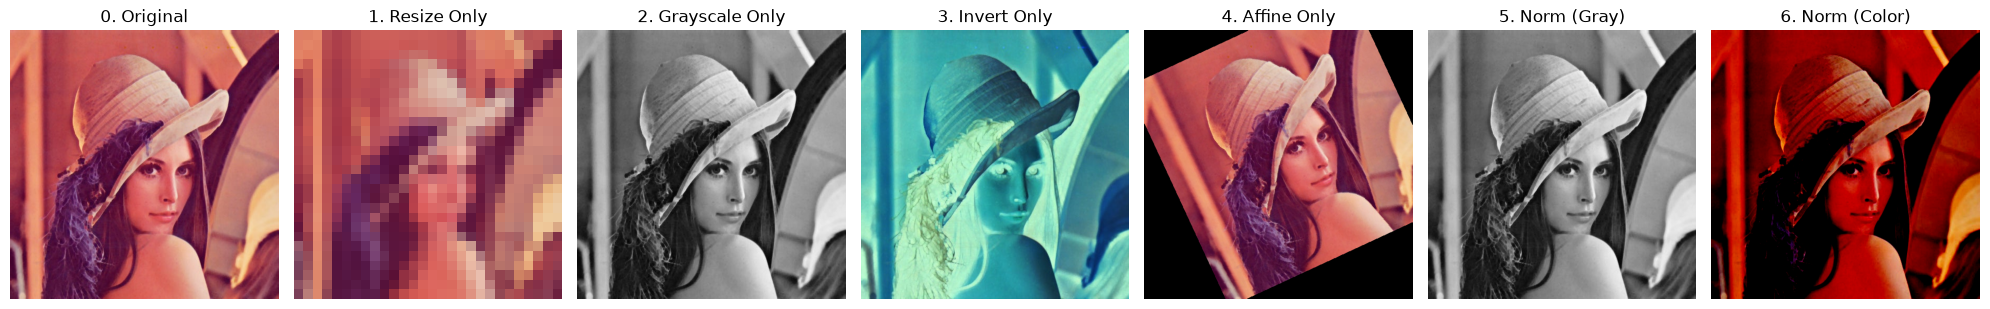


📊 [데이터 수치 변화 확인 (컬러 텐서 기준)]
[1] ToTensor()만 적용 (정규화 전):
 - 데이터 범위 : 0.0000 ~ 1.0000
 - 평균값(mean): 0.4636

[2] Normalize()까지 적용 (정규화 후):
 - 데이터 범위 : -1.0000 ~ 1.0000
 - 평균값(mean): -0.0728
💡 평균값이 0에 가까워지고, 범위가 음수와 양수(-1~1)로 넓어진 것을 확인하세요!



In [9]:
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms

# 1. 로컬 이미지 로드
image_path = './images/123.png' 
try:
    img = Image.open(image_path).convert('RGB')
except FileNotFoundError:
    print(f"'{image_path}' 파일을 찾을 수 없습니다. 경로를 확인해주세요.")
    exit()

# 2. 개별 변환 정의 (1대1 매칭용)
t_resize = transforms.Resize((28, 28))
t_gray = transforms.Grayscale(num_output_channels=1)
t_invert = transforms.RandomInvert(p=1.0)
t_affine = transforms.RandomAffine(degrees=50, translate=(0.08, 0.08), scale=(0.90, 1.10))

# 정규화를 위한 파이프라인
t_tensor = transforms.ToTensor() # 수치 비교용

t_norm_gray = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

t_norm_color = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
])

# 3. 원본(img)에 각각 1대1로 적용 (시각화용)
img_resize = t_resize(img)
img_gray = t_gray(img)
img_invert = t_invert(img)
img_affine = t_affine(img)

tensor_norm_gray = t_norm_gray(img)
tensor_norm_color = t_norm_color(img)

# 시각화를 위해 정규화된 텐서를 0~1 범위로 복원(역정규화) 후 배열로 변환
# img_norm_gray_vis = (tensor_norm_gray * 0.5 + 0.5).squeeze().numpy()
# img_norm_color_vis = (tensor_norm_color * 0.5 + 0.5).permute(1, 2, 0).numpy()
img_norm_gray_vis = tensor_norm_gray.squeeze().numpy()
img_norm_color_vis = tensor_norm_color.permute(1, 2, 0).numpy()

# 4. 시각화 출력 진행
imgs = [img, img_resize, img_gray, img_invert, img_affine, img_norm_gray_vis, img_norm_color_vis]
titles = [
    "0. Original", 
    "1. Resize Only", 
    "2. Grayscale Only", 
    "3. Invert Only", 
    "4. Affine Only",
    "5. Norm (Gray)",
    "6. Norm (Color)"
]

fig, axes = plt.subplots(1, len(imgs), figsize=(20, 3.5))
for i, (ax, image, title) in enumerate(zip(axes, imgs, titles)):
    # 흑백 이미지 처리
    if i in [2, 5]:
        ax.imshow(image, cmap='gray')
    else:
        ax.imshow(image)
    
    ax.set_title(title, fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

# 5. 눈에 보이지 않는 '정규화' 수치 변화 출력
print("\n" + "="*50)
print("📊 [데이터 수치 변화 확인 (컬러 텐서 기준)]")
print("="*50)

# 정규화 전 순수 텐서 (0.0 ~ 1.0)
tensor_img = t_tensor(img) 

print("[1] ToTensor()만 적용 (정규화 전):")
print(f" - 데이터 범위 : {tensor_img.min().item():.4f} ~ {tensor_img.max().item():.4f}")
print(f" - 평균값(mean): {tensor_img.mean().item():.4f}")

print("\n[2] Normalize()까지 적용 (정규화 후):")
print(f" - 데이터 범위 : {tensor_norm_color.min().item():.4f} ~ {tensor_norm_color.max().item():.4f}")
print(f" - 평균값(mean): {tensor_norm_color.mean().item():.4f}")
print("="*50)
print("💡 평균값이 0에 가까워지고, 범위가 음수와 양수(-1~1)로 넓어진 것을 확인하세요!\n")

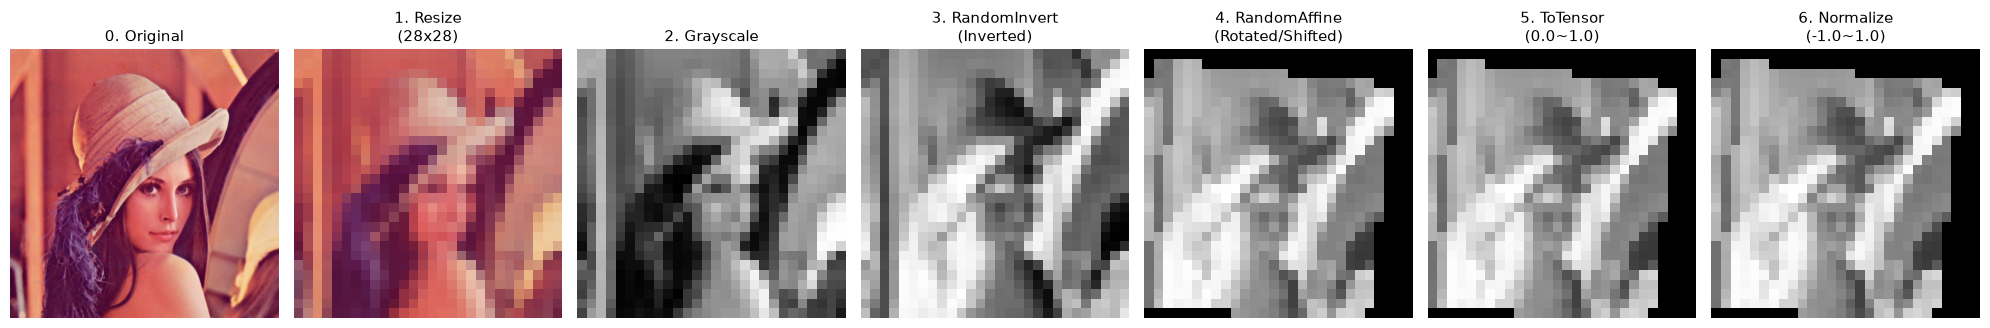

In [10]:
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms

# 1. 로컬에 있는 Lena 이미지 로드
# 다운로드 받으신 파일 이름('image_ebdd45.jpg')과 경로에 맞게 지정해주세요.
image_path = './images/123.png' 
img = Image.open(image_path).convert('RGB')

# 2. 각 변환 단계를 개별적으로 분리
t_resize = transforms.Resize((28, 28))
t_gray = transforms.Grayscale(num_output_channels=1)
t_invert = transforms.RandomInvert(p=1.0)
t_affine = transforms.RandomAffine(degrees=12, translate=(0.08, 0.08), scale=(0.90, 1.10))
t_tensor = transforms.ToTensor()
t_normalize = transforms.Normalize(mean=(0.5,), std=(0.5,))

# 3. 순차적으로 변환을 적용하며 리스트에 저장
imgs = [img]
titles = ["0. Original"]

imgs.append(t_resize(imgs[-1]))
titles.append("1. Resize\n(28x28)")

imgs.append(t_gray(imgs[-1]))
titles.append("2. Grayscale")

imgs.append(t_invert(imgs[-1]))
titles.append("3. RandomInvert\n(Inverted)")

imgs.append(t_affine(imgs[-1]))
titles.append("4. RandomAffine\n(Rotated/Shifted)")

# 5. ToTensor (시각화를 위해 PyTorch Tensor를 NumPy 배열로 변환)
img_tensor = t_tensor(imgs[-1])
imgs.append(img_tensor.squeeze().numpy()) 
titles.append("5. ToTensor\n(0.0~1.0)")

# 6. Normalize (시각화를 위해 역정규화 진행)
img_norm = t_normalize(img_tensor)
img_denorm = img_norm * 0.5 + 0.5 
imgs.append(img_denorm.squeeze().numpy())
titles.append("6. Normalize\n(-1.0~1.0)")

# 4. 전체 과정 나란히 시각화
fig, axes = plt.subplots(1, len(imgs), figsize=(20, 3.5))
for i, (ax, image, title) in enumerate(zip(axes, imgs, titles)):
    # 원본(0번째) 이미지는 컬러이므로 cmap='gray'를 적용하지 않음
    if i == 0:
        ax.imshow(image)
    else:
        ax.imshow(image, cmap='gray')
    ax.set_title(title, fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()

# **4. 학습/검증/테스트 데이터 분리**
- 학습 데이터: 가중치를 실제로 업데이트
- 검증 데이터: 학습 중 모델 선택과 과적합 확인에 사용
- 테스트 데이터: 모든 학습과 모델 선택이 끝난 뒤, 최종 성능을 확인

In [11]:
base_dataset = datasets.ImageFolder(train_dir)
class_names = base_dataset.classes
print(class_names)
num_classes = len(class_names)
print(num_classes)

['cir', 'tri', 'x']
3


In [12]:
print(base_dataset.targets)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


In [13]:
np.where(np.array(base_dataset.targets) == 0)[0]

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79])

In [14]:
train_indices = []
val_indices = []
rng = np.random.default_rng(SEED)

for class_idx in range(num_classes):
    indices = np.where(np.array(base_dataset.targets) == class_idx)[0]
    rng.shuffle(indices)
    split = int(len(indices) * 0.8)
    train_indices.extend(indices[:split].tolist())
    val_indices.extend(indices[split:].tolist())

train_full = datasets.ImageFolder(train_dir, transform=train_transform)
val_full = datasets.ImageFolder(train_dir, transform=eval_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=eval_transform)

# 기존 데이터셋에서 원하는 데이터만 선택하여 새로운 데이터셋을 생성
train_dataset = Subset(train_full, train_indices)
val_dataset = Subset(val_full, val_indices)

print('학습:', len(train_dataset))
print('검증:', len(val_dataset))
print('테스트:', len(test_dataset))

학습: 192
검증: 48
테스트: 60


In [15]:
BATCH_SIZE = 32

# pin_memory=True
# CPU의 일반적인 메모리를 Pageable Memory라고 하고, GPU 전송에 유리하도록 고정된 CPU 메모리를 Pinned Memory라고 함
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)   # num_workers = 사용하고자 하는 cpu코어 수 (0: 전부, -1: 최소, 숫자: 그 숫자만큼)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

# **5. 이미지와 텐서 모양 확인**
- CNN 입력 텐서: [배치, 채널, 높이, 너비]
- 현재 데이터의 배치 shape: [32, 1, 28, 28]

In [16]:
images, labels = next(iter(train_loader))
print('이미지 배치:', images.shape)
print('레이블 배치:', labels.shape)

이미지 배치: torch.Size([32, 1, 28, 28])
레이블 배치: torch.Size([32])


c:\SHJ\KDT\10_MLDL\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [17]:
def denormalize(image):
    return image * 0.5 + 0.5

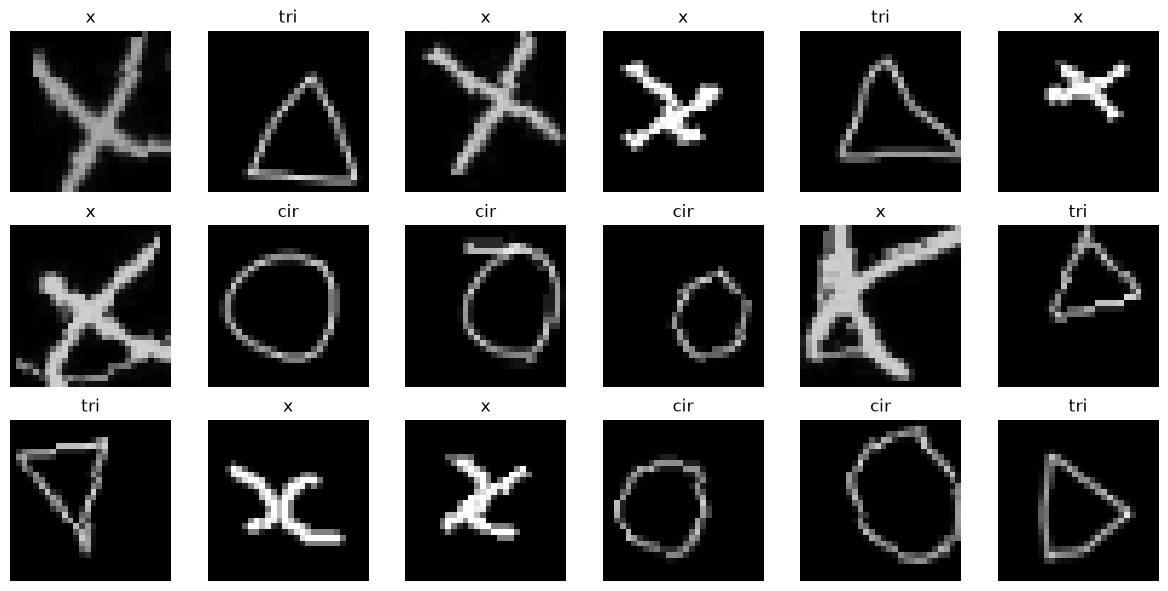

In [18]:
fig, axes = plt.subplots(3, 6, figsize=(12, 6))
for ax, image, label in zip(axes.flat, images[:18], labels[:18]):
    ax.imshow(denormalize(image).squeeze(0), cmap='gray', vmin=0, vmax=1)
    ax.set_title(class_names[label.item()])
    ax.axis('off')
plt.tight_layout()
plt.show()

# **6. CNN 모델**

### BatchNorm2d
CNN이 학습하면서 만들어낸 각 채널(feature map)의 값들을 적절한 범위로 정규화해서 학습을 더 안정적으로 만들어주는 층
```
입력 이미지 > Conv2d > 32개의 Feature Map 생성 > BatchNorm2d > 각 Feature Map의 값들을 정규화 > ReLU
nn.Conv2d(1, 32, kernel_size=3, padding=1, bias=False),
nn.BatchNorm2d(32), # 채널 수
nn.ReLU()
```
> CNN의 Conv2d를 통과하면 값들이 여러가지로 변함. 처음 입력 이미지가 어느 정도 정규화되어 있어도 Conv2d를 통과하고 나면 가중치와 계산되면서 채널마다 값의 분포가 달라질 수 있음.  
> BathchNorm은 값을 어느 정도 정돈해서 다음 층으로 보내주는 역할을 함

### AdaptiveAvgPool2d
- 입력 이미지의 크기가 얼마든 상관없이 최종 출력 크기를 항상 특정 크기로 만들어주는 평균 풀링 레이어
- CNN에서 분류 모델의 마지막 부분에 자주 사용
```
nn.AvgPool2d(kernel_size=2)

1 3 2 4
5 7 6 8
2 4 1 3
6 8 5 7

2*2의 평균을 계산 > (1+3+5+7)/4 = 4

nn.AdaptiveAvgPool2f((1, 1))
입력 크기가 어떻게 생겼든 최종적으로 1*1로 만들어줘

1 2
3 4

(1+2+3+4)/4 = 2.5
Feature Map 하나를 대표하는 값 하나가 만들어짐
```

예)
Conv2d를 통과해서 Feature Map이 64개일 경우  
[32, 64, 14, 14]  
nn.AdaptiveAvgPool2d((1, 1)) 적용  
[32, 64, 1, 1]

> 채널 개수는 그대로 유지되고 H, W만 줄어듦

### Dropout
- 신경망이 학습할 때 일부 뉴런을 일부러 랜덤하게 꺼버리는 기법
- 과적합을 줄이기 위해 사용
- 네트워크에서 뉴런을 영구적으로 삭제하는 것이 아니며, 학습 순간에만 뉴런의 출력을 0으로 함
- model.train()시 Dropout 작동, model.eval()시 Dropout 꺼짐

In [19]:
class ShapeCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace = True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            # inplaces = True: BatchNorm에서 넘어온 Tensor를 별도의 새로운 Tensor로 복사해서 처리하지 말고, Tensor의 메모리를 직접 수정하여 메모리를 절약
            nn.ReLU(inplace = True),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace = True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace = True),
            nn.MaxPool2d(kernel_size=2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(p=0.25),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

In [20]:
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.xpu.is_available():
    DEVICE = torch.device('xpu')
else:
    DEVICE = torch.device('cpu')

print(DEVICE)

cpu


In [21]:
model = ShapeCNN(num_classes=num_classes).to(DEVICE)
model

ShapeCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2

In [22]:
criterion = nn.CrossEntropyLoss()

### AdamW
- Adam에 가중치 감쇠(Weight Decay)를 적용한 방식
- 딥러닝 모델의 가중치가 지나치게 커지면 학습 데이터에 너무 맞춰지는 과적합이 발생할 수 있음 > Weight Decay로 학습 중에 가중치를 조금씩 줄여서 너무 커지지 않도록 하는 방법을 사용
- 과적합을 줄이고 일반화 성능을 높이도록 만듦
```
Gradient > Adam의 적응적 계산 > 가중치 업데이트 > Weight Decay를 적용
```

In [23]:
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

### Scheduler
- 검증 성능이 더 이상 좋아지지 않을 때 자동으로 학습률을 낮춰주는 기능
- 가중치 = 가중치 - 학습률 * 기울기
```
Epoch1 Loss: 0.8
Epoch2 Loss: 0.6
Epoch3 Loss: 0.5
Epoch4 Loss: 0.43
Epoch5 Loss: 0.40  # 이후로 Loss가 좋아지지 않음
Epoch6 Loss: 0.41
Epoch7 Loss: 0.42
Epoch8 Loss: 0.41
```
- mode: 무엇을 기준으로 좋아졌다고 판단할지를 결정
- factor: 학습률 반영 값
- patience: 몇 번까지 참아줄 것이지 설정

In [24]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

### 학습과 평가 함수

In [25]:
def run_epoch(model, loader, criterion, device, optimizer=None):
    is_training = optimizer is not None
    model.train() if is_training else model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    # enable_grad: 기울기 계산을 활성화
    # inference_mode(): 메모리 사용량 감소. 불필요한 기울기 계산 방지. 실행 속도 향상
    context = torch.enable_grad() if is_training else torch.inference_mode()
    with context:
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            if is_training:
                # set_to_none=True: 기울기 값을 0으로 채우는 대신 None으로 설정
                # 메모리 사용을 줄일 수 있음. 불필요한 0 텐서 생성을 줄임
                optimizer.zero_grad(set_to_none=True)
            model = model.to(device)
            logits = model(images)
            loss = criterion(logits, labels)
            if is_training:
                loss.backward()
                optimizer.step()
            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_samples += batch_size
    return total_loss / total_samples, total_correct / total_samples


### 모델 학습과 Early Stopping
- 검증 손실이 가장 낮을 때의 가중치를 저장
- 일정 횟수 동안 검증 손실이 개선되지 않으면 학습을 조기에 종료하여 과적합과 불필요한 학습을 줄임

In [26]:
EPOCHS = 50
EARLY_STOPPING_PATIENCE = 8
best_val_loss = float('inf')
wait = 0
history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
best_model_path = 'best_shape_cnn.pth'

In [27]:
for epoch in range(1, EPOCHS+1):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, DEVICE, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion, DEVICE)
    scheduler.step(val_loss)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    current_lr = optimizer.param_groups[0]['lr']

    print(
        f'Epoch {epoch:02d}/{EPOCHS} | '
        f'train loss {train_loss:.4f}, acc {train_acc*100:6.2f}% | '
        f'val loss {val_loss:.4f}, acc {val_acc*100:6.2f}% | '
        f'lr {current_lr:.6f}'
    )

    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        wait = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        wait += 1
        if wait >= EARLY_STOPPING_PATIENCE:
            print('검증 손실이 더 이상 개선되지 않아 학습을 종료합니다')
            break

Epoch 01/50 | train loss 0.7967, acc  57.29% | val loss 1.0293, acc  45.83% | lr 0.001000
Epoch 02/50 | train loss 0.6026, acc  69.27% | val loss 0.8266, acc  66.67% | lr 0.001000
Epoch 03/50 | train loss 0.5354, acc  77.08% | val loss 0.7125, acc  66.67% | lr 0.001000
Epoch 04/50 | train loss 0.4898, acc  78.65% | val loss 0.6612, acc  66.67% | lr 0.001000
Epoch 05/50 | train loss 0.4617, acc  77.08% | val loss 0.6097, acc  75.00% | lr 0.001000
Epoch 06/50 | train loss 0.4234, acc  84.90% | val loss 0.5362, acc  77.08% | lr 0.001000
Epoch 07/50 | train loss 0.3981, acc  84.38% | val loss 0.4732, acc  79.17% | lr 0.001000
Epoch 08/50 | train loss 0.3797, acc  86.98% | val loss 0.4667, acc  75.00% | lr 0.001000
Epoch 09/50 | train loss 0.3329, acc  88.54% | val loss 0.3350, acc  87.50% | lr 0.001000
Epoch 10/50 | train loss 0.2969, acc  91.15% | val loss 0.3392, acc  81.25% | lr 0.001000
Epoch 11/50 | train loss 0.2889, acc  91.15% | val loss 0.2811, acc  91.67% | lr 0.001000
Epoch 12/5

# **7. 학습 곡선으로 과적합 확인**
- 학습 손실과 검증 손실이 함께 감소하면 정상적인 학습에 가까움
- 학습 손실은 계속 감소하지만, 검증 손실이 증가하면 과적합 가능성이 큼
- 학습/검증 정확도가 모두 낮으면 모델 용량, 전처리, 학습률, 데이터 품질 등을 점검해야 함

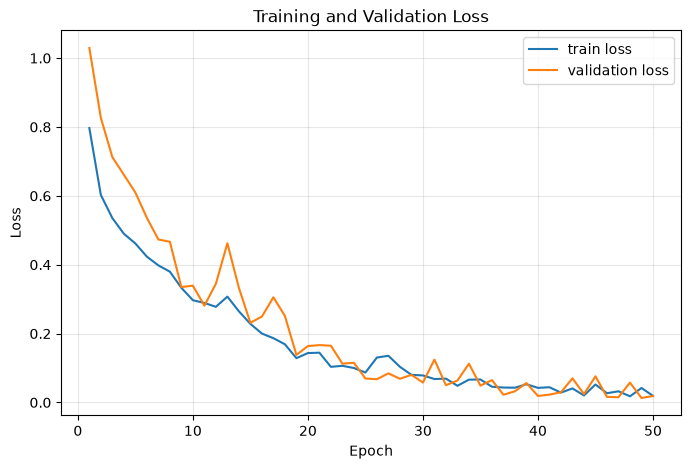

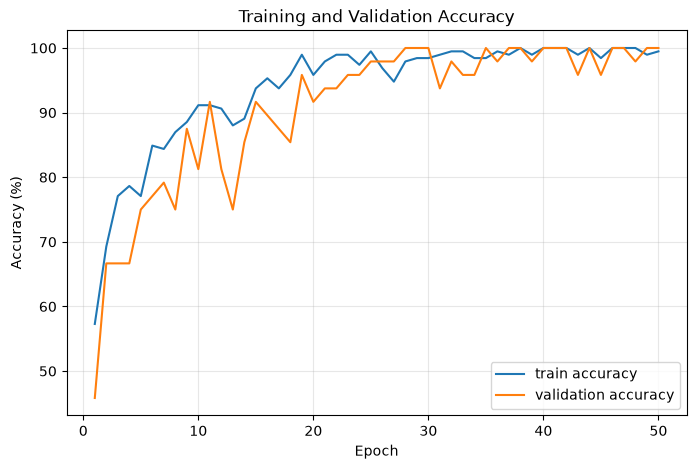

In [28]:
epochs_ran = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history['train_loss'], label='train loss')
plt.plot(epochs_ran, history['val_loss'], label='validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, np.array(history['train_acc']) * 100, label='train accuracy')
plt.plot(epochs_ran, np.array(history['val_acc']) * 100, label='validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# **8. 학습된 모델로 테스트 평가**
### 학습되지 않은 모델로 테스트 평가

In [32]:
model = ShapeCNN(num_classes=num_classes).to(DEVICE)
model

ShapeCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2

In [31]:
test_loss, test_acc = run_epoch(model, test_loader, criterion, DEVICE)
print(f'테스트 Loss: {test_loss:.4f}')
print(f'테스트 acc: {test_acc * 100:.2f}%')

테스트 Loss: 1.1025
테스트 acc: 33.33%


c:\SHJ\KDT\10_MLDL\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


### 가중치를 불러와 모델에 적용한 후 테스트 평가

In [33]:
model = ShapeCNN(num_classes).to(DEVICE)
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE, weights_only=True))

<All keys matched successfully>

In [34]:
test_loss, test_acc = run_epoch(model, test_loader, criterion, DEVICE)
print(f'테스트 Loss: {test_loss:.4f}')
print(f'테스트 acc: {test_acc * 100:.2f}%')

테스트 Loss: 0.0370
테스트 acc: 98.33%


c:\SHJ\KDT\10_MLDL\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


# **9. 혼동행렬과 클래스별 성능**
- 전체 정확도가 높아도 특정 클래스만 자주 틀릴 수 있음
- 혼동행렬은 실제 클래스와 예측 클래스의 조합을 볼 수 있음
- 대각선 값이 클수록 올바르게 분류한 이미지가 많다는 뜻

In [36]:
def collect_predictions(model, loader):
    model.eval()
    all_images = []
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.inference_mode():
        for images, labels in loader:
            logits = model(images.to(DEVICE))
            probs = torch.softmax(logits, dim=1).cpu()
            preds = probs.argmax(dim=1)

            all_images.append(images.cpu())
            all_labels.append(labels.cpu())
            all_preds.append(preds)
            all_probs.append(probs)

    return (
        torch.cat(all_images),
        torch.cat(all_labels),
        torch.cat(all_preds),
        torch.cat(all_probs),
    )

In [37]:
test_images, y_true, y_pred, y_prob = collect_predictions(model, test_loader)

c:\SHJ\KDT\10_MLDL\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [38]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

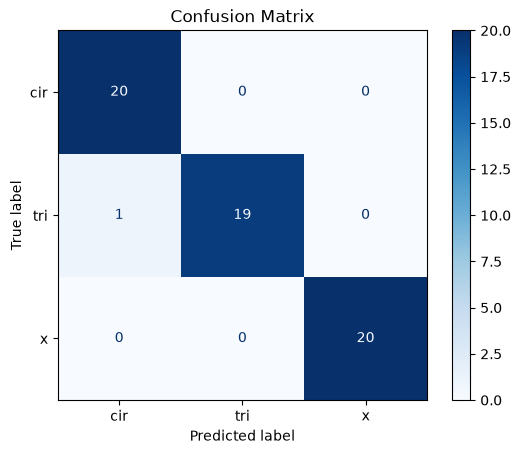

              precision    recall  f1-score   support

         cir     0.9524    1.0000    0.9756        20
         tri     1.0000    0.9500    0.9744        20
           x     1.0000    1.0000    1.0000        20

    accuracy                         0.9833        60
   macro avg     0.9841    0.9833    0.9833        60
weighted avg     0.9841    0.9833    0.9833        60



In [43]:
cm = confusion_matrix(y_true.numpy(), y_pred.numpy())
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
display.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(
    y_true.numpy(),
    y_pred.numpy(),
    target_names=class_names,
    digits=4,
    zero_division=0,
))

# precision : 모델이 True로 분류한 것중 실제로 True인 비율
# recall : 실제 해당 클래스 중에서 모델이 찾아낸 비율
# f1-score : precision, recall 조합 평균
# support : 클래스의 개수

# macro avg : 다중 분류 모델에서 전체 데이터의 True Positive(TP), False Positive(FP), False Negative(FN) 개수를 모두 더한 뒤, 이를 바탕으로 정밀도(Precision), 재현율(Recall), F1 점수를 한 번에 계산하는 방법
# weighted avg : 자료의 평균을 구할 때 자료 값의 중요도나 영향 정도에 해당하는 가중치를 반영하여 구한 평균값이다. 모든 가중치가 동일할 경우, 가중 평균은 산술 평균과 동일

# **10. 오분류 이미지 분석**
- 모델일 틀린 이미지에는 데이터 품질, 모호한 이미지, 전처리 문제, 부족한 학습 데이터 등 중요한 단서가 들어가 있음
- 단순히 정확도만 보는 것보다 오분류 사례를 직접 확인하는 것이 모델 개선에 매우 중요

In [41]:
wrong_indices = torch.where(y_true != y_pred)[0]

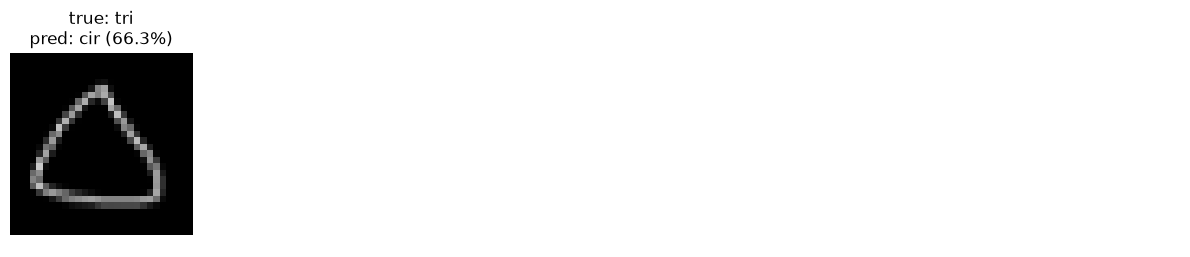

In [42]:
if len(wrong_indices) == 0:
    print('현재 테스트 데이터에서 오분류 이미지가 없습니다.')
else:
    show_count = min(18, len(wrong_indices))
    selected = wrong_indices[:show_count]
    rows = int(np.ceil(show_count / 6))
    fig, axes = plt.subplots(rows, 6, figsize=(12, 2.5 * rows))
    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis('off')

    for ax, idx in zip(axes, selected):
        true_idx = y_true[idx].item()
        pred_idx = y_pred[idx].item()
        confidence = y_prob[idx, pred_idx].item() * 100
        ax.imshow(denormalize(test_images[idx]).squeeze(0), cmap='gray', vmin=0, vmax=1)
        ax.set_title(
            f'true: {class_names[true_idx]}\n'
            f'pred: {class_names[pred_idx]} ({confidence:.1f}%)'
        )
        ax.axis('off')

    plt.tight_layout()
    plt.show()

### 성능을 더 높일 때 점검할 순서
1. 잘못된 레이블이나 지나치게 모호한 그림이 없는 지 확인
2. 실제 사용 환경과 학습 데이터의 배경색/선 굵기/크기 차이를 줄임
3. 클래스별 데이터를 더 다양하게 수집
4. 증강 강도를 조금씩 바꿔 검증 성능을 비교
5. 데이터가 충분히 늘어난 뒤 모델 크기와 학습률을 조절
> 이 데이터는 전체 300장으로 매우 작음. 테스트 정확도가 높더라도 실제 손글씨 전체를 대표한다고 단정할 수 없음. 새로운 사람이 그린 별도의 데이터도 추가 검증해야 함